In [1]:
import json
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import functools
import random

In [2]:
dataset_name = "minds"
# refs = [15, 18, 19, 21, 23, 24, 27, 28, 29, 30, 31, 54, 55]
refs = [15] #, 62]

In [3]:
if dataset_name == "minds":
    dataset_normalized_name = "MINDS-Libras"
    num_person = 12
    categories = ["To happen", "Student", "Yellow", "America", "To enjoy", "Candy", "Bank", "Bathroom", "Noise", "Five", "To know", "Mirror", "Corner", "Son", "Apple", "Fear", "Bad", "Frog", "Vaccine", "Will"]
if dataset_name == "ufop":
    dataset_normalized_name = "LIBRAS-UFOP"
    num_person = 5
    categories = ["Year 1", "Year 2", "Year 3", "Day 1", "Day 2", "Day 3", "Week 1", "Week", "Yesterday", "Day before yesterday", "Safe", "Physiotherapy", "Idea", "Stamp", "Record", "Effort", "Defend", "Physical education", "Bodybuilding", "Battle", "Close", "Screw up", "Bicycle", "Slip", "Always", "Build", "Calumny", "Work", "Television", "Love", "Learn", "Analyze", "Talk", "Cock", "Hen", "Interact", "Exchange", "Strong wind", "Weak wind", "Strong rain", "Weak rain", "Run fast", "Run slow", "Takes great care", "Takes a little care", "Thin", "Fat", "Strong", "Weak", "Arrive", "Win", "Loss", "Open", "Nothing", "Nobody", "Not"]
    categories_1 = ["Year 1", "Year 2", "Year 3", "Day 1", "Day 2", "Day 3", "Week 1", "Week", "Yesterday", "Day before yesterday"]
    categories_2 = ["Safe", "Physiotherapy", "Idea", "Day 1", "Stamp", "Record", "Effort", "Defend", "Physical education", "Bodybuilding", "Battle", "Close", "Screw up", "Bicycle", "Slip", "Always", "Build", "Calumny", "Work", "Television"]
    categories_3 = ["Love", "Learn", "Analyze", "Talk", "Cock", "Hen", "Interact", "Exchange"]
    categories_4 = ["Strong wind", "Weak wind", "Strong rain", "Weak rain", "Run fast", "Run slow", "Takes great care", "Takes a little care", "Thin", "Fat", "Strong", "Weak", "Arrive", "Win", "Loss", "Open", "Close", "Nothing", "Nobody", "Not"]

if dataset_name == "ksl":
    dataset_normalized_name = "KSL"
    original_categories = ["hi", "what", "meat", "bi bim rice", "glad", "hobby", "me", "movie", "face", "see", "name", "read", "thank", "equal", "sorry", "eat", "fine", "do effort", "next", "age", "again", "how many", "day", "good, nice", "when", "we", "subway", "be friendly", "bus", "ride", "cell phone", "where", "number", "location", "guide", "responsibility", "who", "arrive", "family", "time", "introduction", "recieve", "please?", "walk", "parents", "10 minutes", "sister", "study", "human", "now", "special", "yesterday", "education", "test", "end", "you", "worried_about", "marry", "effort", "no", "sweat", "yet", "finally", "born", "success", "favor", "Seoul", "dinner", "experience", "invite", "food", "want", "visit", "one hour", "far", "good", "care"]
    categories = [i.capitalize() for j, i in enumerate(original_categories) if (j + 1) not in (12, 19, 28, 33, 35, 45, 46, 53, 73, 75)]
    num_person = 20

if dataset_name == "include50" or dataset_name == "include50_new":
    categories = ['Loud', 'Mean', 'Rich', 'Poor', 'Thick', 'Thin', 'Expensive', 'Cheap', 'Flat', 'Curved', 'Male', 'Quiet', 'Female', 'Tight', 'Loose', 'High', 'Low', 'Soft', 'Hard', 'Deep', 'Shallow', 'Clean', 'Happy', 'Dirty', 'Strong', 'Weak', 'Dead', 'Alive', 'Heavy', 'Light', 'Famous', 'Sad', 'Beautiful', 'Ugly', 'Deaf', 'Long', 'Short', 'Blind', 'Tall', 'Wide', 'Narrow', 'Big large', 'Small little', 'Slow', 'Fast', 'Hot', 'Cold', 'Warm', 'Nice', 'Cool', 'New', 'Old', 'Young', 'Good', 'Bad', 'Wet', 'Dry', 'Sick', 'Healthy', 'Dog', 'Cat', 'Fish', 'Bird', 'Cow', 'Mouse', 'Horse', 'Animal', 'Hat', 'Dress', 'Suit', 'Skirt', 'Shirt', 'T-shirt', 'Pant', 'Shoes', 'Pocket', 'Clothing', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Today', 'Tomorrow', 'Yesterday', 'Week', 'Month', 'Year', 'Hour', 'Minute', 'Second', 'Morning', 'Afternoon', 'Evening', 'Night', 'Time', 'Clock', 'Lamp', 'Fan', 'Cell phone', 'Computer', 'Laptop', 'Screen', 'Camera', 'Television', 'Radio', 'Hello', 'How are you', 'Alright', 'Good morning', 'Good afternoon', 'Good evening', 'Good night', 'Thank you', 'Pleased', 'Table', 'Chair', 'Bed', 'Dream', 'Window', 'Door', 'Bedroom', 'Kitchen', 'Bathroom', 'Pencil', 'Pen', 'Photograph', 'Soap', 'Book', 'Page', 'Key', 'Paint', 'Letter', 'Paper', 'Lock', 'Telephone', 'Bag', 'Box', 'Gift', 'Card', 'Ring', 'Tool', 'Teacher', 'Student', 'Lawyer', 'Doctor', 'Patient', 'Waiter', 'Secretary', 'Priest', 'Police', 'Soldier', 'Artist', 'Author', 'Manager', 'Reporter', 'Actor', 'Job', 'Plane', 'Car', 'Truck', 'Bicycle', 'Bus', 'Boat', 'Train ticket', 'Transportation', 'Train', 'Son', 'Daughter', 'Mother', 'Father', 'Parent', 'Baby', 'Man', 'Woman', 'Brother', 'Sister', 'Family', 'Grandfather', 'Grandmother', 'Husband', 'Wife', 'King', 'Queen', 'President', 'Neighbour', 'Boy', 'Girl', 'Child', 'Adult', 'Friend', 'Player', 'Crowd', 'City', 'House', 'Street or road', 'Train station', 'Restaurant', 'Court', 'School', 'Office', 'University', 'Park', 'Store or shop', 'Library', 'Hospital', 'Temple', 'Market', 'India', 'Ground', 'Bank', 'Location', 'I', 'You', 'He', 'She', 'It', 'We', 'You (plural)', 'They', 'Summer', 'Spring', 'Winter', 'Fall', 'Season', 'Monsoon', 'Religion', 'Energy', 'War', 'Peace', 'Attack', 'Election', 'Newspaper', 'Gun', 'Sport', 'Exercise', 'Ball', 'Death', 'Price', 'Sign', 'Science', 'God', 'Medicine', 'Money', 'Bill', 'Marriage', 'Team', 'Race (ethnicity)', 'Technology']
    num_person = 0

In [4]:
all_results = {}
for ref in refs:
    results = []
    results_path = f"../99_model_output/results/{ref}/{dataset_name}/"
    for file in os.listdir(results_path):
        if file.endswith(".json"):
            with open(os.path.join(results_path, file), "r") as f:
                results.append(json.load(f))
    all_results[ref] = results

In [5]:
for ref in refs:
    accuracies = [max(train["history"]["accuracy"]) for train in all_results[ref]]
    val_accuracies = [max(train["history"]["val_accuracy"]) for train in all_results[ref]]
    print(f"Ref {ref}:")
    print(f"Min Accuracy: {min(accuracies)} - ({accuracies.index(min(accuracies))})")
    print(f"Max Accuracy: {max(accuracies)} - ({accuracies.index(max(accuracies))})")
    print(f"Min Val Accuracy: {min(val_accuracies)} - ({val_accuracies.index(min(val_accuracies))})")
    print(f"Max Val Accuracy: {max(val_accuracies)} - ({val_accuracies.index(max(val_accuracies))})")
    print("\n" * 2)

Ref 15:
Min Accuracy: 0.9688473520249221 - (37)
Max Accuracy: 1.0 - (3)
Min Val Accuracy: 0.8235294117647058 - (29)
Max Val Accuracy: 1.0 - (19)





In [6]:
def plot_all_folds(ref, field):
    results = all_results[ref]
    if dataset_name == "minds":
        results = results[:12]
    if dataset_name == "ufop":
        results = results[:5]
    accuracies = [train["history"][field] for train in results]
    fig = plt.figure()
    fig.set_dpi(200)
    for a in accuracies:
        plt.plot(a)
    plt.legend([f"Fold {i + 1}" for i in range(len(accuracies))], bbox_to_anchor=(1, 1))
    
        
def show_all_folds(ref):
    results = all_results[ref]
    if dataset_name == "minds":
        results = results[:12]
    if dataset_name == "ufop":
        results = results[:5]
    accuracies = [train["history"]["accuracy"] for train in results]
    for i, a in enumerate(accuracies):
        print(f"{i + 1}: {max(a)} - ({len(a)})")
        
def compare_results(ref):
    results = all_results[ref]
    index = random.randint(0, len(all_results[ref][0]["true_labels"]) - 1)
    true_labels = [train["true_labels"] for train in all_results[ref]]
    predicted_labels = [train["predicted_labels"] for train in all_results[ref]]
    values = zip(true_labels, predicted_labels)
    correct_sign = all_results[ref][0]['true_labels'][index]
    print(f"Correct sign: {correct_sign}")
    results = []
    for i, p in enumerate(predicted_labels):
        print(f"{i + 1}: {correct_sign} - ({p[index]})")
        results.append({
            "fold": i + 1,
            "true_label": correct_sign,
            "predicted_label": p[index]
        })
    df = pd.DataFrame.from_records(results)
    df = df.set_index("fold")
    return df

In [7]:
def compare_wrong_results(ref, fold):
    fold -= 1
    results = all_results[ref]
    if dataset_name == "minds":
        results = results[:12]
    if dataset_name == "ufop":
        results = results[:5]
    index = random.randint(0, len(results[0]["true_labels"]) - 1)
    true_labels = [train["true_labels"] for train in results]
    predicted_labels = [train["predicted_labels"] for train in results]
    
    true_fold_labels =results[fold]["true_labels"]
    predicted_fold_labels = results[fold]["predicted_labels"]
    
    wrong_indexes = [i for i in range(len(predicted_fold_labels)) if true_fold_labels[i] != predicted_fold_labels[i]]
    print(wrong_indexes)
    index = random.randint(0, len(wrong_indexes) - 1)
    index = wrong_indexes[index]
    
    values = zip(true_labels, predicted_labels)
    correct_sign = results[0]['true_labels'][index]
    print(f"Correct sign: {correct_sign}")
    fold_results = []
    for i, v in enumerate(values):
        c, p = v
        test_people = [str(k) for k in results[i]["test_people"]]
        person_count = 1
        fold_result = {
            "fold": i + 1,
            "test_people": ", ".join(test_people),
            "true_label": categories[correct_sign],
        }
        for j in range(len(c)):
            if c[j] == correct_sign:
                fold_result["video_" + str(person_count)] = categories[p[j]]
                person_count += 1
        fold_results.append(fold_result)
    df = pd.DataFrame.from_records(fold_results)
    df = df.set_index("fold")
    df = df.fillna("-")
    return df

In [8]:
def compare_wrong_results_by_sign(ref, sign):
    results = all_results[ref]
    if dataset_name == "minds":
        results = results[:12]
    if dataset_name == "ufop":
        results = results[:5]
    index = random.randint(0, len(results[0]["true_labels"]) - 1)
    true_labels = [train["true_labels"] for train in results]
    predicted_labels = [train["predicted_labels"] for train in results]
    
    values = zip(true_labels, predicted_labels)
    correct_sign = categories.index(sign)
    print(f"Correct sign: {correct_sign}")
    fold_results = []
    for i, v in enumerate(values):
        c, p = v
        test_people = [str(k) for k in results[i]["test_people"]]
        person_count = 1
        fold_result = {
            "fold": i + 1,
            "test_people": ", ".join(test_people),
            "true_label": categories[correct_sign],
        }
        for j in range(len(c)):
            if c[j] == correct_sign:
                fold_result["video_" + str(person_count)] = categories[p[j]]
                person_count += 1
        fold_results.append(fold_result)
    df = pd.DataFrame.from_records(fold_results)
    df = df.set_index("fold")
    df = df.fillna("-")
    return df

In [9]:
ref = 15

In [10]:
compare_wrong_results(ref, 4)

[75, 76, 77, 78, 79, 90, 93]
Correct sign: 15


,test_people,true_label,video_1,video_2,video_3,video_4,video_5
fold,,,,,,,
1,2,Fear,Fear,Fear,Fear,Fear,Fear
2,3,Fear,Fear,Fear,Fear,Fear,Son
3,4,Fear,Fear,Fear,Fear,Fear,Fear
4,5,Fear,Bad,Bad,Bad,Bad,Bad
5,6,Fear,Fear,Fear,Fear,Fear,Fear
6,7,Fear,Fear,Fear,Fear,Fear,Fear
7,8,Fear,Fear,Fear,Fear,Fear,Fear
8,9,Fear,-,-,-,-,-
9,10,Fear,Fear,Fear,Vaccine,Fear,Fear


In [11]:
compare_wrong_results_by_sign(ref, "America")

Correct sign: 3


,test_people,true_label,video_1,video_2,video_3,video_4,video_5
fold,,,,,,,
1,2,America,America,America,America,America,America
2,3,America,-,-,-,-,-
3,4,America,America,America,America,America,America
4,5,America,America,America,America,America,America
5,6,America,America,America,America,America,America
6,7,America,America,America,America,America,America
7,8,America,America,America,America,America,America
8,9,America,America,America,America,America,America
9,10,America,America,America,America,America,America


Text(0.5, 0, 'Epoch')

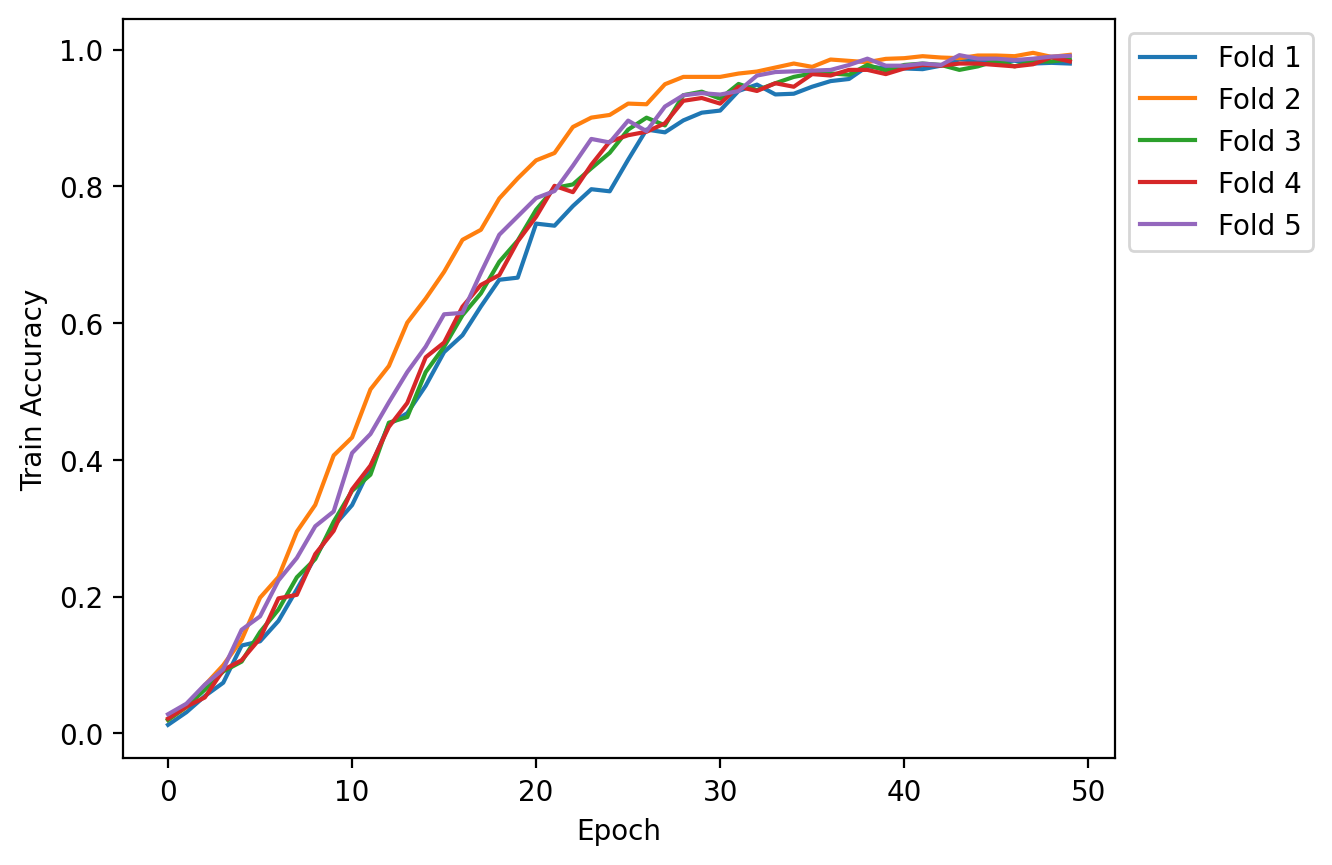

In [59]:
plot_all_folds(ref, "accuracy")
plt.ylabel("Train Accuracy")
plt.xlabel("Epoch")

Text(0.5, 0, 'Epoch')

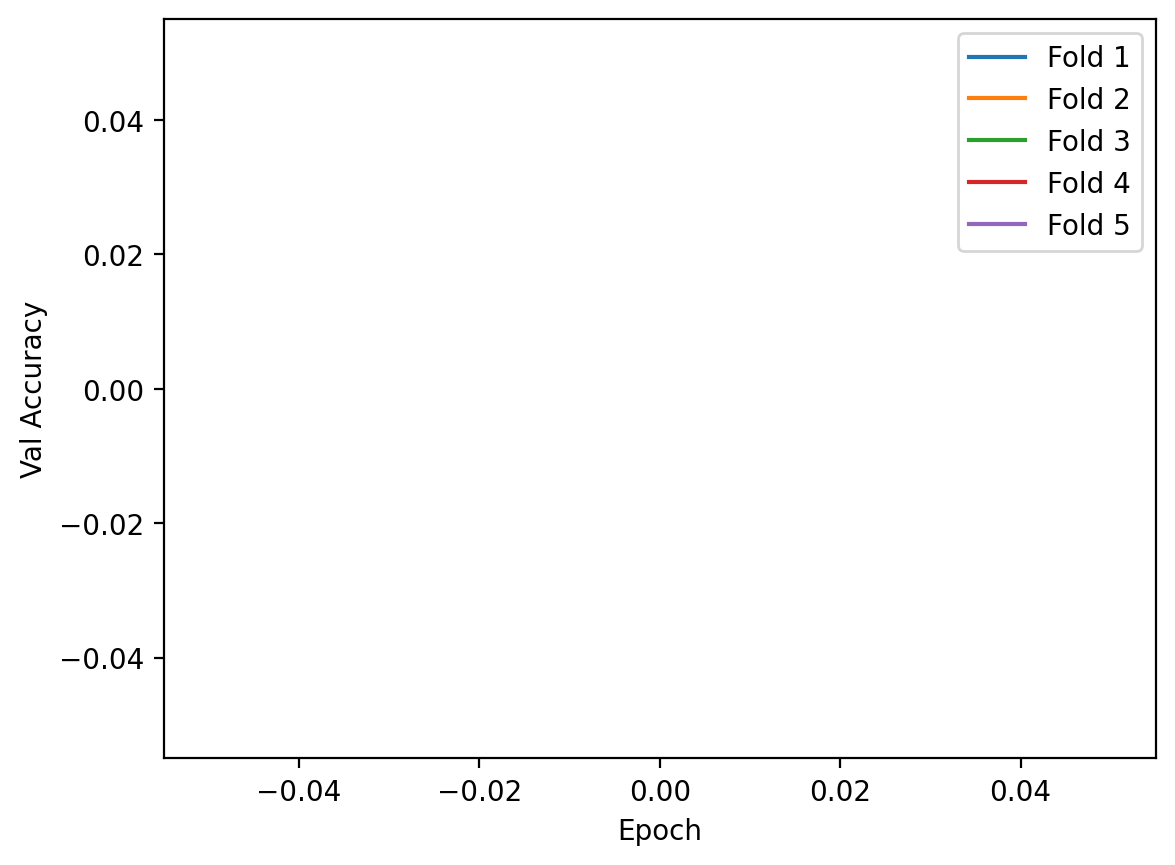

In [60]:
plot_all_folds(ref, "val_accuracy")
plt.ylabel("Val Accuracy")
plt.xlabel("Epoch")

Text(0.5, 0, 'Epoch')

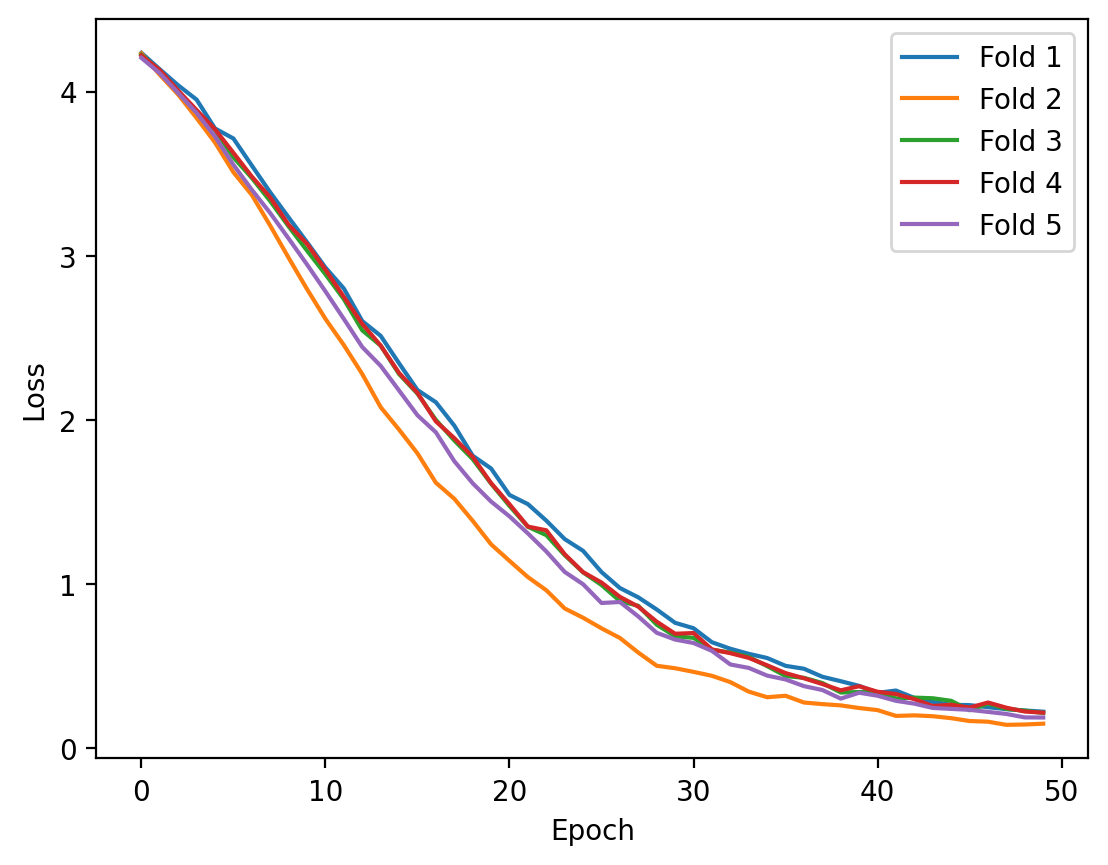

In [61]:
plot_all_folds(ref, "loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

In [62]:
show_all_folds(ref)

1: 0.9856262833675564 - (50)
2: 0.9951171875 - (50)
3: 0.9856115107913669 - (50)
4: 0.9886947584789312 - (50)
5: 0.9917610710607621 - (50)


In [63]:
all_results[ref][3]

{'dataset_name': 'ksl',
 'frames': 1,
 'seed': 1638102311,
 'epochs': 50,
 'last_epoch': 49,
 'optimizer_parameters': {'lr': 0.0001, 'weight_decay': 0.0001},
 'test_people': [12, 13, 14, 15],
 'validate_people': [],
 'resnet_fc_layer': 'Sequential(\n  (0): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)\n  (1): Linear(in_features=512, out_features=128, bias=True)\n  (2): ReLU()\n  (3): Dropout(p=0.5, inplace=False)\n  (4): Linear(in_features=128, out_features=67, bias=True)\n)',
 'history': {'loss': [4.219800349252197,
   4.130827809164237,
   4.006174556030399,
   3.887677741810327,
   3.7703112909017094,
   3.6271334853471244,
   3.482607310501914,
   3.355156833809424,
   3.188930641832969,
   3.0729258528471237,
   2.9157265560722547,
   2.750009067257041,
   2.5855865005599017,
   2.453825349307869,
   2.2867054826554143,
   2.1653806773633653,
   1.991783854405167,
   1.889962956692185,
   1.77587045721503,
   1.616005630556873,
   1.4872366678800

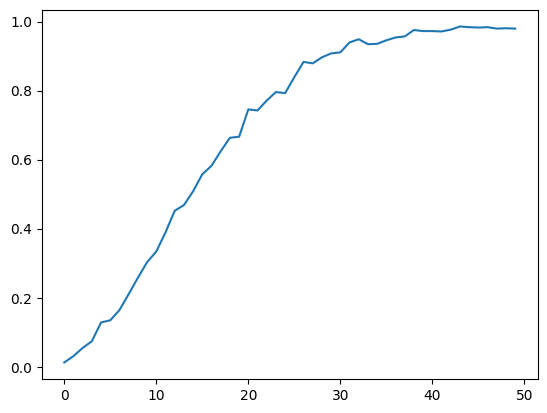

In [64]:
plt.plot(all_results[ref][0]["history"]["accuracy"])

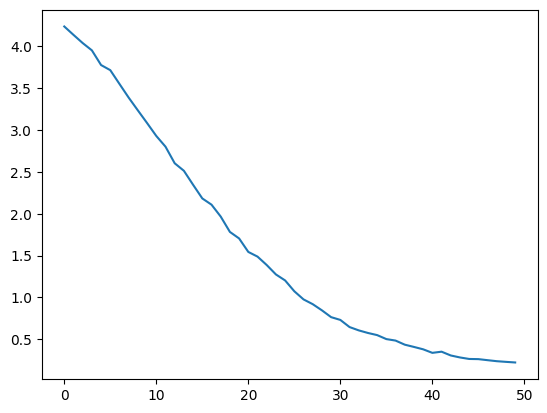

In [65]:
plt.plot(all_results[ref][0]["history"]["loss"])

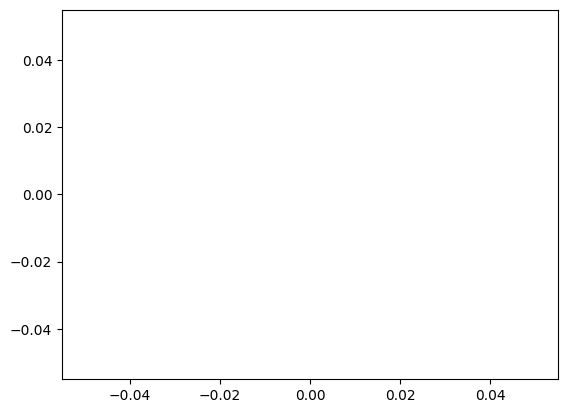

In [66]:
plt.plot(all_results[ref][0]["history"]["val_accuracy"])

In [67]:
accuracies

[0.9856262833675564,
 0.9951171875,
 0.9856115107913669,
 0.9886947584789312,
 0.9917610710607621]